***Descriptive Analysis***

***About Dataset***

***The Preprocessed Google Play Store Dataset now contains processed information about mobile applications available on the Google Play Store.
It includes 9,659 rows and 15 columns, where each row represents one unique mobile application with metadata such as category, ratings, installs, pricing structure, and update history.
This dataset is useful for EDA, app market analysis, user engagement insights, and trend identification.***

* ***App***: *The name or title of the application listed on the Play Store.*

* ***Category***: *The broad category under which the app is classified (e.g., TOOLS, SOCIAL, GAME, COMMUNICATION, SPORTS).*

* ***Rating***: *Average user rating of the app on a 1–5 scale. Missing values indicate unrated or newly added apps.*

* ***Reviews***: *Total number of user reviews submitted for the app on the Play Store.*

* ***Size_MB***: *The size of the application in megabytes (MB). Some apps may show extremely small sizes due to cloud or lightweight design.*

* ***Installs***: *The number of times an app has been installed, represented numerically.*

* ***Type***: *Indicates whether the app is Free or Paid.*

* ***Price_$***: *Price of the app in US dollars. Free apps have a value of 0.0.*

* ***Content Rating***: *Age-group classification assigned to the app (e.g., Everyone, Teen, Mature 17+).*

* ***Genres***: *A more specific genre of the app beyond the general category (e.g., Action, Social, Sports Simulation).*

* ***Last Updated***: *The date on which the app was last updated on the Play Store.*

* ***Current Ver***: *The current version number of the app posted on the store.*

* ***Android Ver***: *The minimum Android OS version required for the app to run.*

* ***Last_Updated_Year***: *Extracted numeric year value from the Last Updated column (e.g., 2017, 2018).*

* ***Primary_Genre***: *A standardized version of the app’s main category or genre used for analysis.*


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import kagglehub
import os

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

path = kagglehub.dataset_download("vikaseranki9/google-play-store-cleaned")

print("Path to dataset files:", path)

csv_path = None
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

if csv_path is None:
    raise FileNotFoundError(f"No .csv file found in {path}")

df = pd.read_csv(csv_path)



Path to dataset files: /Users/meenakshsinghania04/.cache/kagglehub/datasets/vikaseranki9/google-play-store-cleaned/versions/1


In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (8479, 15)
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size_MB', 'Installs', 'Type', 'Price_$', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Last_Updated_Year', 'Primary_Genre']


In [4]:
df.head()

,App,Category,Rating,Reviews,Size_MB,Installs,Type,Price_$,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last_Updated_Year,Primary_Genre
0,"""i DT"" Fútbol. Todos Somos Técnicos.",SPORTS,4.3,27,3.6,500,Free,0.0,Everyone,Sports,2017-10-07,0.22,4.1,2017,Sports
1,+Download 4 Instagram Twitter,SOCIAL,4.5,40467,22.0,1000000,Free,0.0,Everyone,Social,2018-08-02,5.03,4.1,2018,Social
2,- Free Comics - Comic Apps,COMICS,3.5,115,9.1,10000,Free,0.0,Mature 17+,Comics,2018-07-13,5.0.12,5.0,2018,Comics
3,.R,TOOLS,4.5,259,0.2,10000,Free,0.0,Everyone,Tools,2014-09-16,1.1.06,1.5,2014,Tools
4,/u/app,COMMUNICATION,4.7,573,53.0,10000,Free,0.0,Mature 17+,Communication,2018-07-03,4.2.4,4.1,2018,Communication


In [5]:
df.describe()

,Rating,Reviews,Size_MB,Installs,Price_$,Last_Updated_Year
count,8479.000000,8479.000000,8479.000000,8.479000e+03,8479.000000,8479.000000
mean,4.216818,10514.211346,19.214588,5.842451e+05,1.166656,2017.296025
std,0.410258,16132.854139,18.484238,9.035485e+05,17.447873,1.170677
min,3.250000,0.000000,0.010000,0.000000e+00,0.000000,2010.000000
25%,4.000000,18.000000,4.600000,1.000000e+03,0.000000,2017.000000
50%,4.300000,513.000000,12.000000,5.000000e+04,0.000000,2018.000000
75%,4.500000,16546.500000,28.000000,1.000000e+06,0.000000,2018.000000
max,5.000000,41339.000000,63.100000,2.498500e+06,400.000000,2018.000000


In [6]:
df.columns = [
    'app', 'category', 'rating', 'reviews', 'size_mb', 'installs',
    'type', 'price_usd', 'content_rating', 'genres',
    'last_updated', 'current_ver', 'android_ver',
    'last_updated_year', 'primary_genre'
]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8479 entries, 0 to 8478
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   app                8479 non-null   object 
 1   category           8479 non-null   object 
 2   rating             8479 non-null   float64
 3   reviews            8479 non-null   int64  
 4   size_mb            8479 non-null   float64
 5   installs           8479 non-null   int64  
 6   type               8479 non-null   object 
 7   price_usd          8479 non-null   float64
 8   content_rating     8479 non-null   object 
 9   genres             8479 non-null   object 
 10  last_updated       8479 non-null   object 
 11  current_ver        8479 non-null   object 
 12  android_ver        8479 non-null   object 
 13  last_updated_year  8479 non-null   int64  
 14  primary_genre      8479 non-null   object 
dtypes: float64(3), int64(3), object(9)
memory usage: 993.8+ KB


In [8]:
def compute_stats(series):
    data = series.dropna().values

    mean = np.mean(data)
    median = np.median(data)
    mode = stats.mode(data, keepdims=True)[0][0]
    std = np.std(data)

    p25 = np.percentile(data, 25)
    p75 = np.percentile(data, 75)
    iqr = p75 - p25
    lower = p25 - 1.5 * iqr
    upper = p75 + 1.5 * iqr

    outliers = data[(data < lower) | (data > upper)]

    z = stats.zscore(data)
    anomalies = data[np.abs(z) > 3]

    return {
        "mean": mean,
        "median": median,
        "mode": mode,
        "std_dev": std,
        "iqr": iqr,
        "outliers_count": len(outliers),
        "anomalies_count": len(anomalies)
    }


In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

In [10]:
numerical_col_results = {}

for col in num_cols:
    numerical_col_results[col] = compute_stats(df[col])

numerical_col_results

{'rating': {'mean': np.float64(4.216818020993041),
  'median': np.float64(4.3),
  'mode': np.float64(4.3),
  'std_dev': np.float64(0.4102339188428597),
  'iqr': np.float64(0.5),
  'outliers_count': 0,
  'anomalies_count': 0},
 'reviews': {'mean': np.float64(10514.211345677557),
  'median': np.float64(513.0),
  'mode': np.int64(41339),
  'std_dev': np.float64(16131.902768967804),
  'iqr': np.float64(16528.5),
  'outliers_count': 0,
  'anomalies_count': 0},
 'size_mb': {'mean': np.float64(19.214587805165703),
  'median': np.float64(12.0),
  'mode': np.float64(63.099999999999994),
  'std_dev': np.float64(18.483147522009485),
  'iqr': np.float64(23.4),
  'outliers_count': 0,
  'anomalies_count': 0},
 'installs': {'mean': np.float64(584245.0570822031),
  'median': np.float64(50000.0),
  'mode': np.int64(2498500),
  'std_dev': np.float64(903495.2067271455),
  'iqr': np.float64(999000.0),
  'outliers_count': 0,
  'anomalies_count': 0},
 'price_usd': {'mean': np.float64(1.1666564453355348),
  

In [11]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

In [12]:
encoder = LabelEncoder()
df_cat_encoded = df[categorical_cols].apply(encoder.fit_transform)

In [13]:
scaler = StandardScaler()
df_cat_scaled = pd.DataFrame(scaler.fit_transform(df_cat_encoded), columns=categorical_cols)

In [14]:
categorical_results = {}

for col in df_cat_scaled.columns:
    categorical_results[col] = compute_stats(df_cat_scaled[col])

categorical_results

{'app': {'mean': np.float64(-3.3520119625432255e-17),
  'median': np.float64(0.0),
  'mode': np.float64(-1.7318465442498618),
  'std_dev': np.float64(1.0),
  'iqr': np.float64(1.731846544249862),
  'outliers_count': 0,
  'anomalies_count': 0},
 'category': {'mean': np.float64(-1.7556162653820142e-16),
  'median': np.float64(-0.3078664090136874),
  'mode': np.float64(-0.6691340127448845),
  'std_dev': np.float64(1.0),
  'iqr': np.float64(1.5654929495018544),
  'outliers_count': 0,
  'anomalies_count': 0},
 'type': {'mean': np.float64(4.357615551306193e-17),
  'median': np.float64(-0.29457193078179),
  'mode': np.float64(-0.29457193078179),
  'std_dev': np.float64(0.9999999999999999),
  'iqr': np.float64(0.0),
  'outliers_count': 677,
  'anomalies_count': 677},
 'content_rating': {'mean': np.float64(3.142511214884274e-17),
  'median': np.float64(-0.43969296928132445),
  'mode': np.float64(-0.43969296928132445),
  'std_dev': np.float64(1.0),
  'iqr': np.float64(0.0),
  'outliers_count': 1

***Explanatory Data Analysis***

***In this section, we will explore the Preprocessed Google Play Store dataset to understand better through visualizations:***
- *App ratings*
- *Installs and reviews*
- *Category-wise distribution*
- *Price patterns*
- *Content rating and genres*
- *Key relationships between important variables*


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 150
sns.set(style="whitegrid")

***1. Distribution of App Ratings***

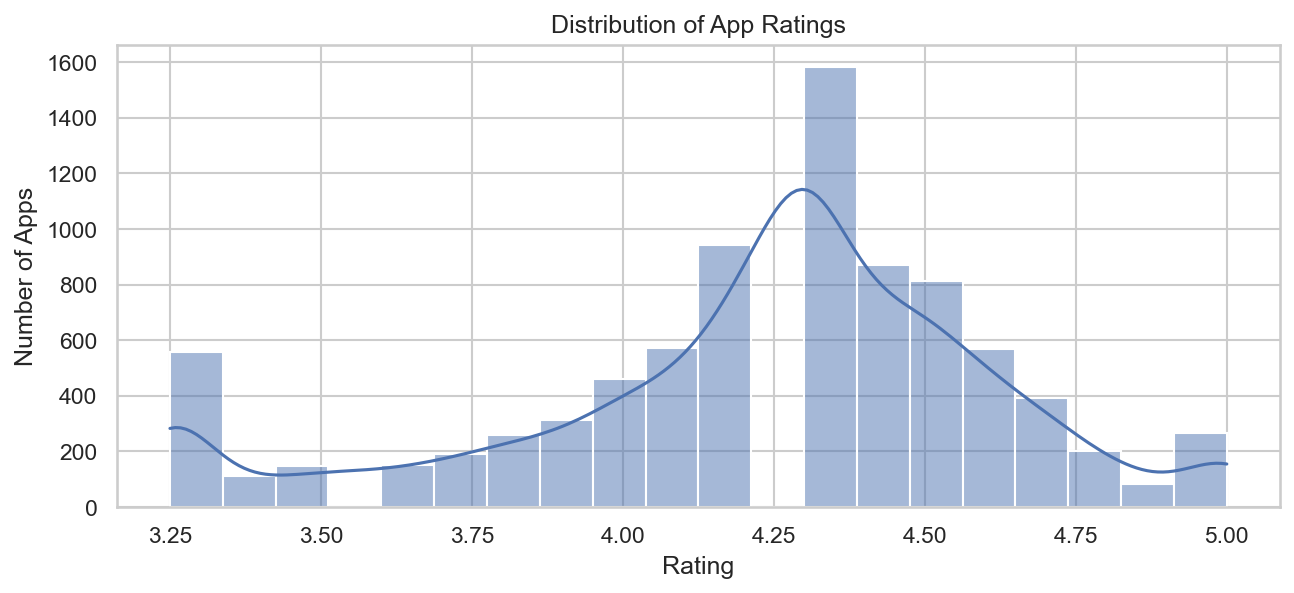

In [16]:
plt.figure(figsize=(10,4))
sns.histplot(
    data=df,
    x='rating',
    bins=20,
    kde=True
)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()


***Key Findings:***
- *Most apps have ratings between **4.0 and 4.6**, indicating generally positive user feedback.*
- *Very few apps have ratings below **3.5**, suggesting that poorly rated apps are rare or removed from the store.*
- *The distribution is slightly **left-skewed**, with a concentration of high ratings.*


***2. Distribution of Installs***

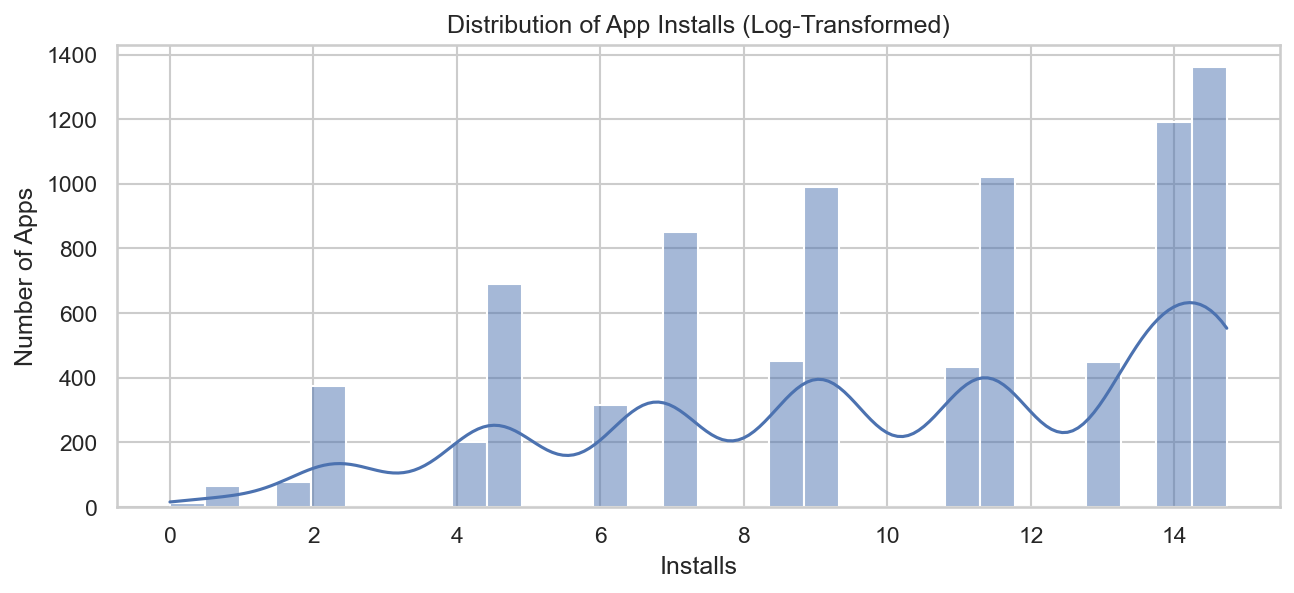

In [17]:
df['installs_log'] = np.log1p(df['installs']) #We applied a log transform because app installs are highly skewed. It reduces extreme values and makes the distribution more balanced and closer to normal.

plt.figure(figsize=(10,4))
sns.histplot(
    data=df,
    x='installs_log',
    bins=30,
    kde=True
)
plt.title("Distribution of App Installs (Log-Transformed)")
plt.xlabel("Installs")
plt.ylabel("Number of Apps")
plt.show()


***Key Findings:***
- *Installs are **heavily right-skewed** in raw form, dominated by a few very popular apps.*
- *After log transformation, the distribution becomes smoother, revealing clusters of moderately and highly installed apps.*


***3. Distribution of User Reviews***

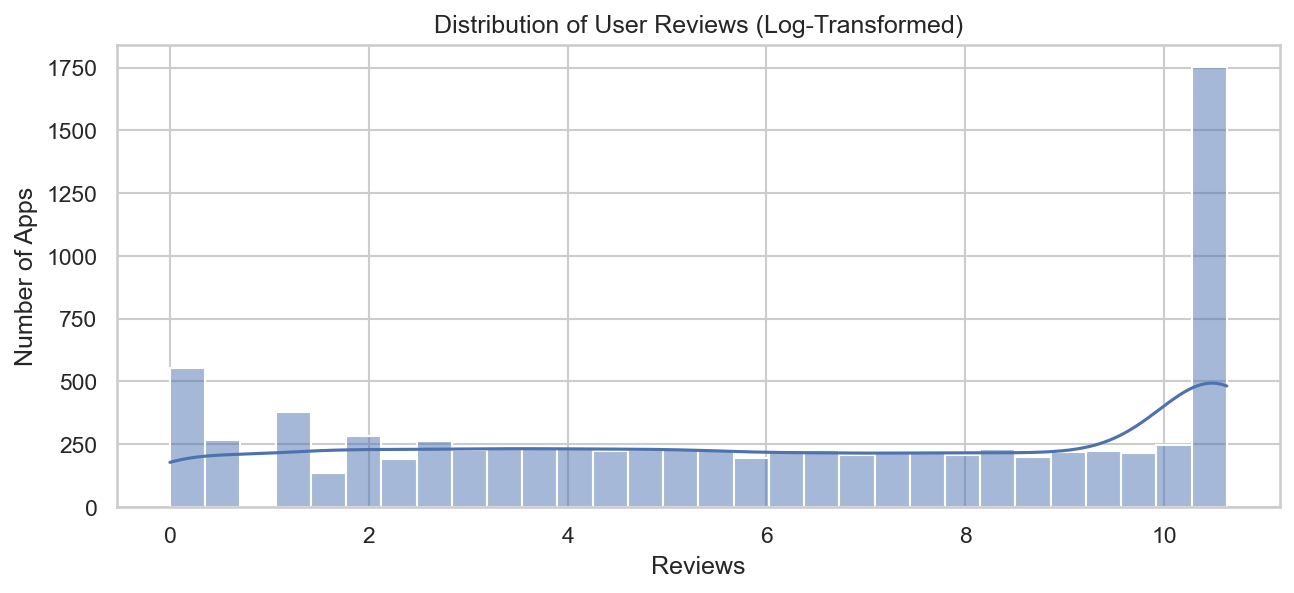

In [18]:
df['reviews_log'] = np.log1p(df['reviews']) #We applied a log transform because app installs are highly skewed. It reduces extreme values and makes the distribution more balanced and closer to normal.

plt.figure(figsize=(10,4))
sns.histplot(
    data=df,
    x='reviews_log',
    bins=30,
    kde=True
)
plt.title("Distribution of User Reviews (Log-Transformed)")
plt.xlabel("Reviews")
plt.ylabel("Number of Apps")
plt.show()


***Key Findings:***
- *Most apps have relatively few reviews, while a small set of apps gathers a very large number of reviews.*
- *This mirrors the pattern of installs — a **winner-takes-most** dynamic in the app ecosystem.*


***4. Number of Apps by Category***


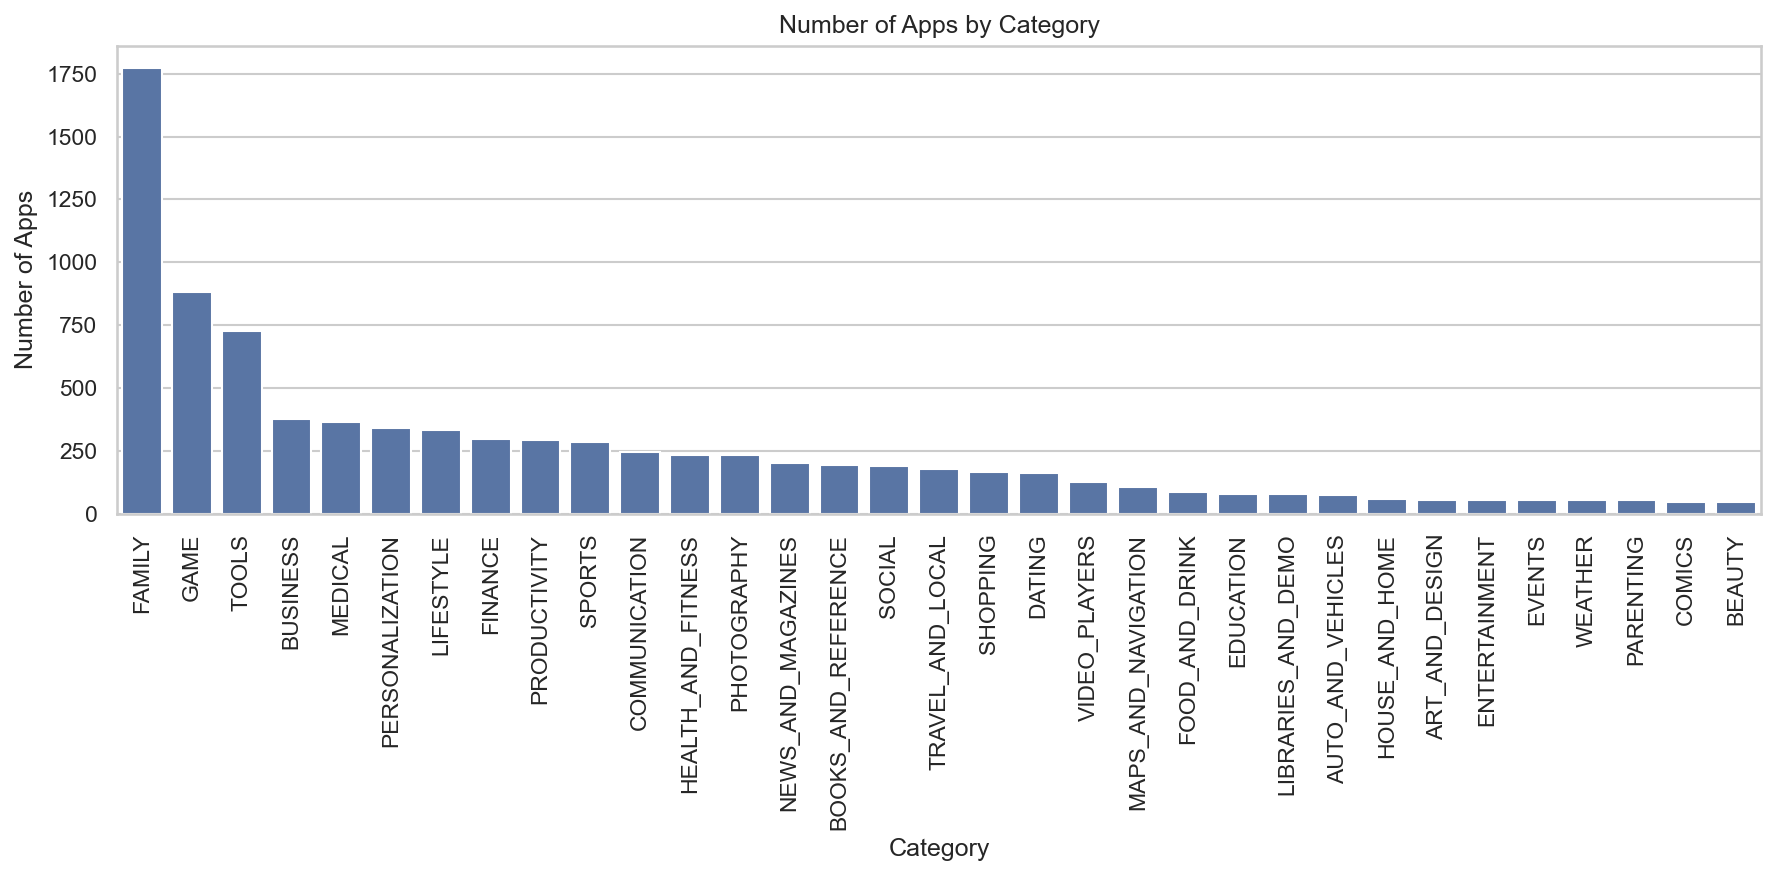

In [19]:
plt.figure(figsize=(12,6))
category_counts = df['category'].value_counts().sort_values(ascending=False)

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)
plt.xticks(rotation=90)
plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()


***Key Findings:***
- *Categories like **FAMILY**, **TOOLS**, **GAME**, and **COMMUNICATION** have the highest app counts.*
- *Niche categories have fewer apps, indicating specialized or less saturated markets.*


***5. Average Rating by Category***

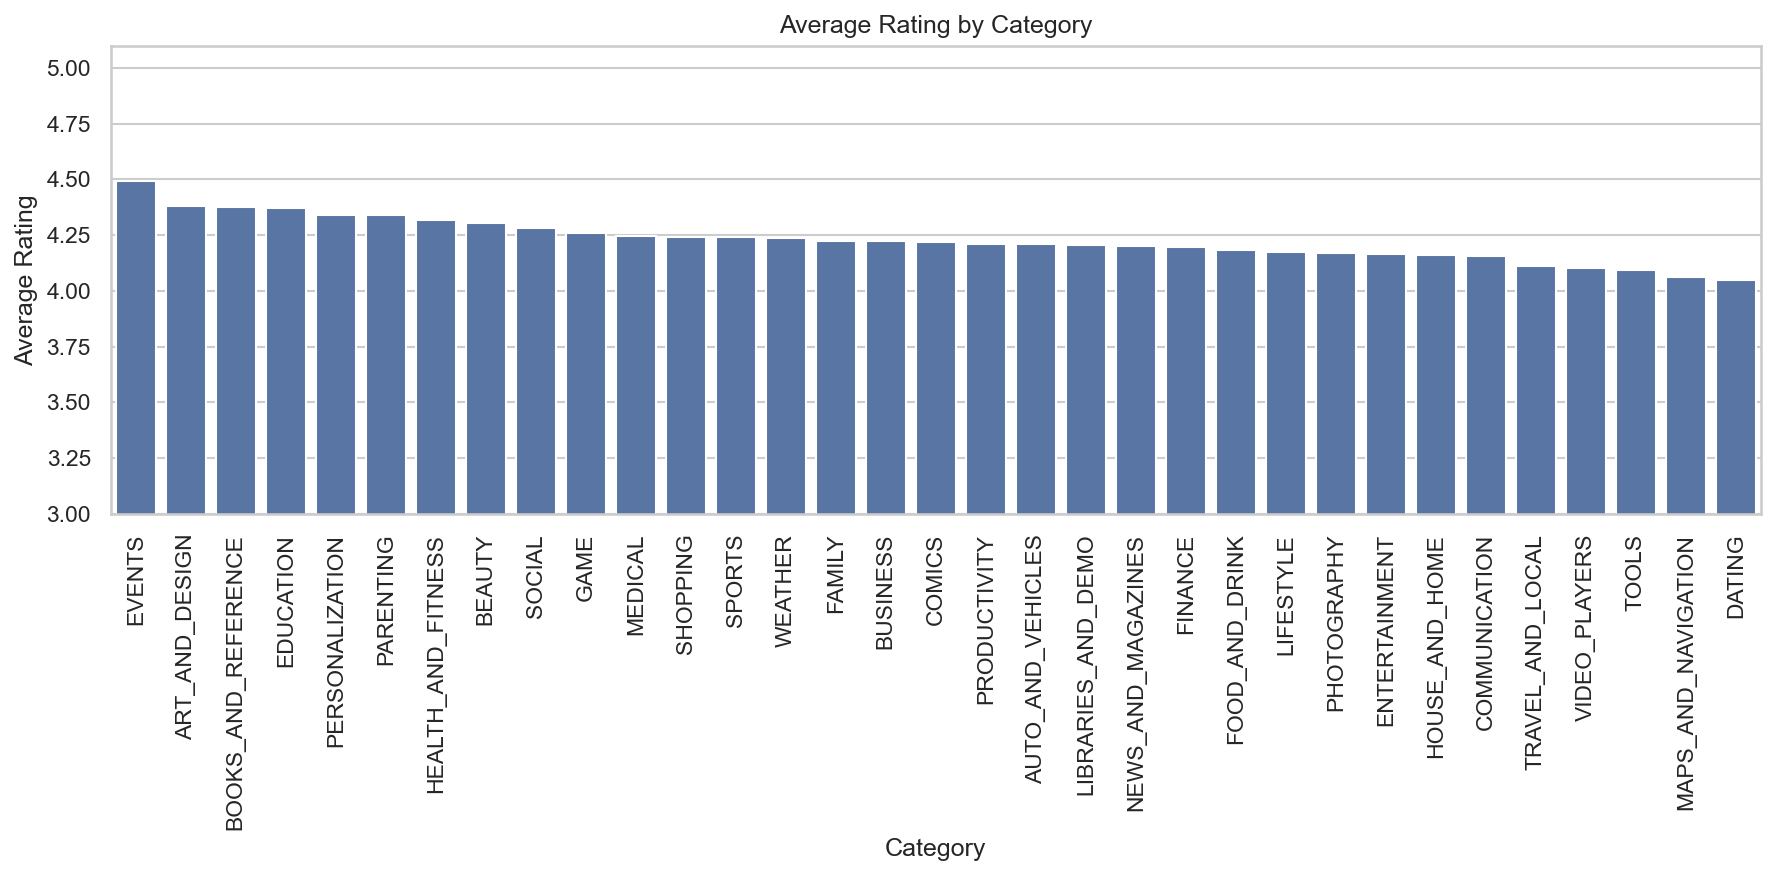

In [20]:
rating_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x=rating_by_category.index,
    y=rating_by_category.values
)
plt.xticks(rotation=90)
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(3.0, 5.1)
plt.tight_layout()
plt.show()


***Key Findings:***
- *Some categories consistently maintain higher ratings, suggesting better user satisfaction or more polished apps.*
- *Categories with lower average ratings may indicate usability issues, performance concerns, or misaligned expectations.*


***6. Content Rating Distribution***


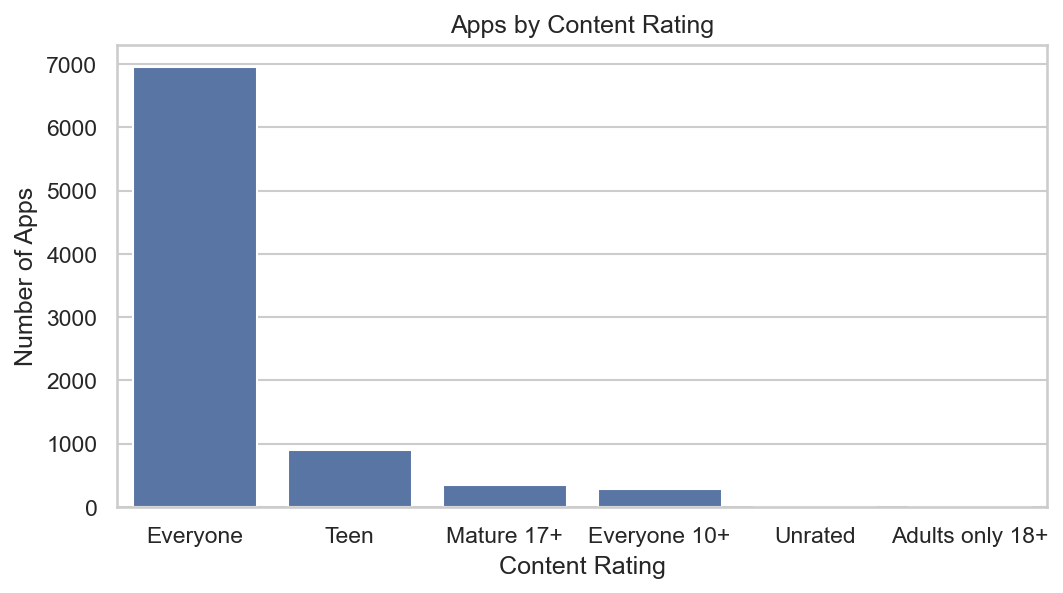

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='content_rating', order=df['content_rating'].value_counts().index)
plt.title("Apps by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")
plt.show()


***Key Findings:***
- *Most apps are rated **"Everyone"**, showing that the Play Store heavily caters to general audiences.*
- *Specific age-restricted ratings (like Teen / Mature) form smaller but important subsets.*


***7. Free vs Paid Apps***


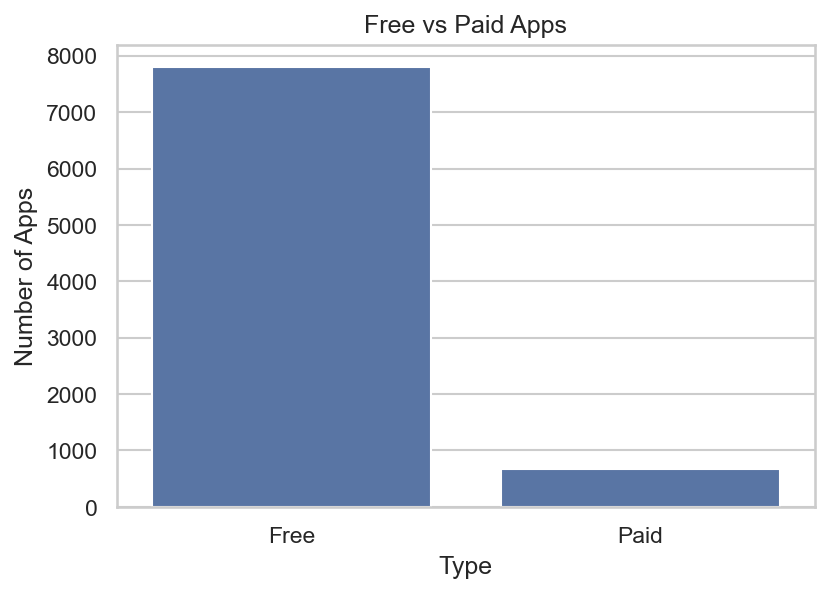

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Free vs Paid Apps")
plt.xlabel("Type")
plt.ylabel("Number of Apps")
plt.show()


***Key Findings:***
- *The ecosystem is dominated by **Free** apps.*
- *Paid apps are relatively rare and likely target niche or professional users.*


***8. Price Distribution for Paid Apps***

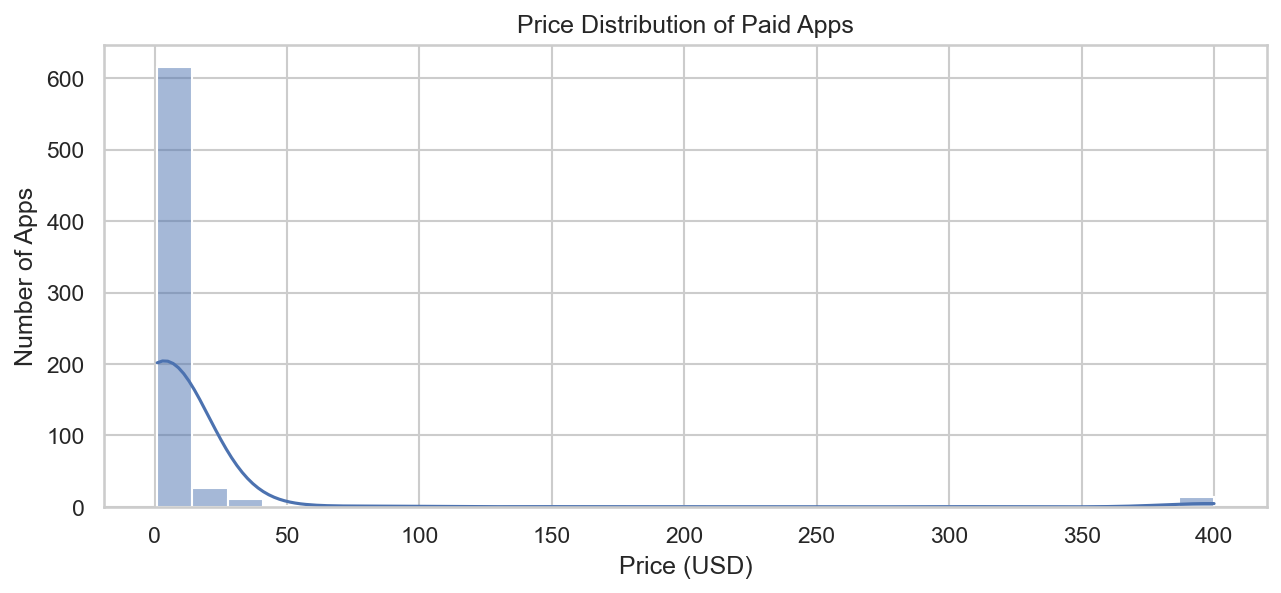

In [23]:
paid_apps = df[df['type'] == 'Paid']

plt.figure(figsize=(10,4))
sns.histplot(
    data=paid_apps,
    x='price_usd',
    bins=30,
    kde=True
)
plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Apps")
plt.show()


***9. Relationship Between Installs and Reviews***


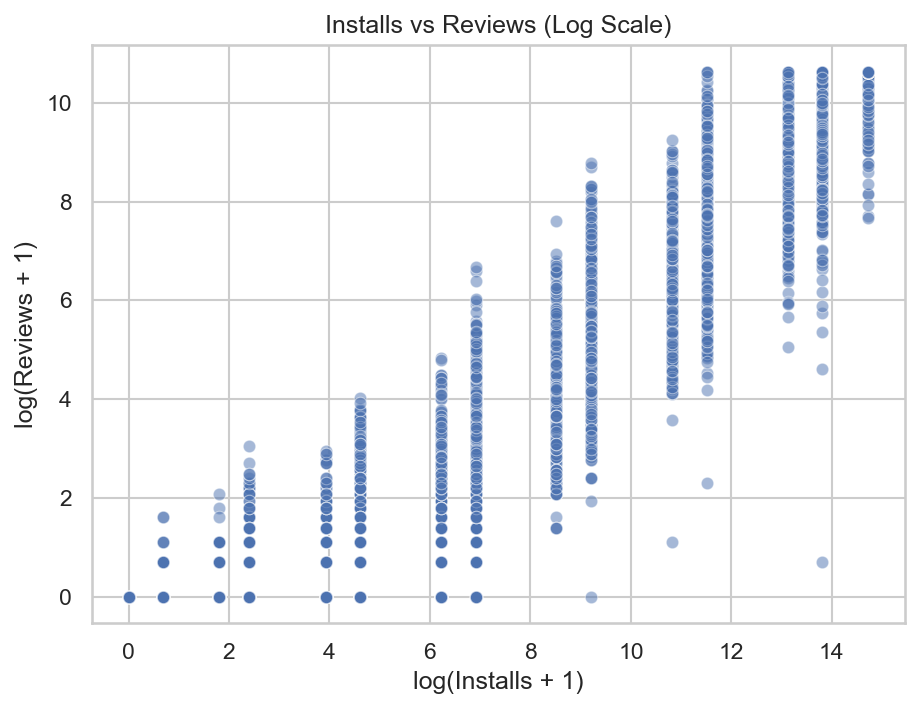

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='installs_log',
    y='reviews_log',
    alpha=0.5
)
plt.title("Installs vs Reviews (Log Scale)")
plt.xlabel("log(Installs + 1)")
plt.ylabel("log(Reviews + 1)")
plt.show()


***Key Findings:***
- *There is a clear positive relationship between installs and reviews.*
- *Apps with more users naturally accumulate more feedback, reinforcing **social proof dynamics**.*


***10. Relationship Between Rating and Installs***

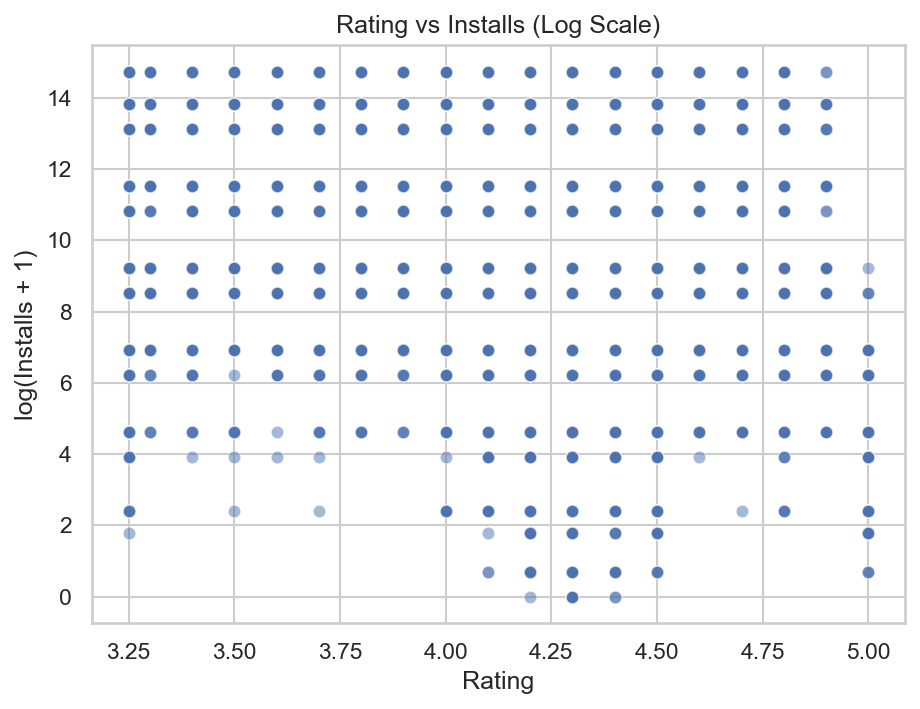

In [25]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='rating',
    y='installs_log',
    alpha=0.5
)
plt.title("Rating vs Installs (Log Scale)")
plt.xlabel("Rating")
plt.ylabel("log(Installs + 1)")
plt.show()


***Key Findings:***
- *Ratings do **not** strongly determine how many installs an app has.*
- *Some apps with average ratings still achieve very high installs — likely due to brand, marketing, or early entry.*


***11. Correlation Between Numerical Features***

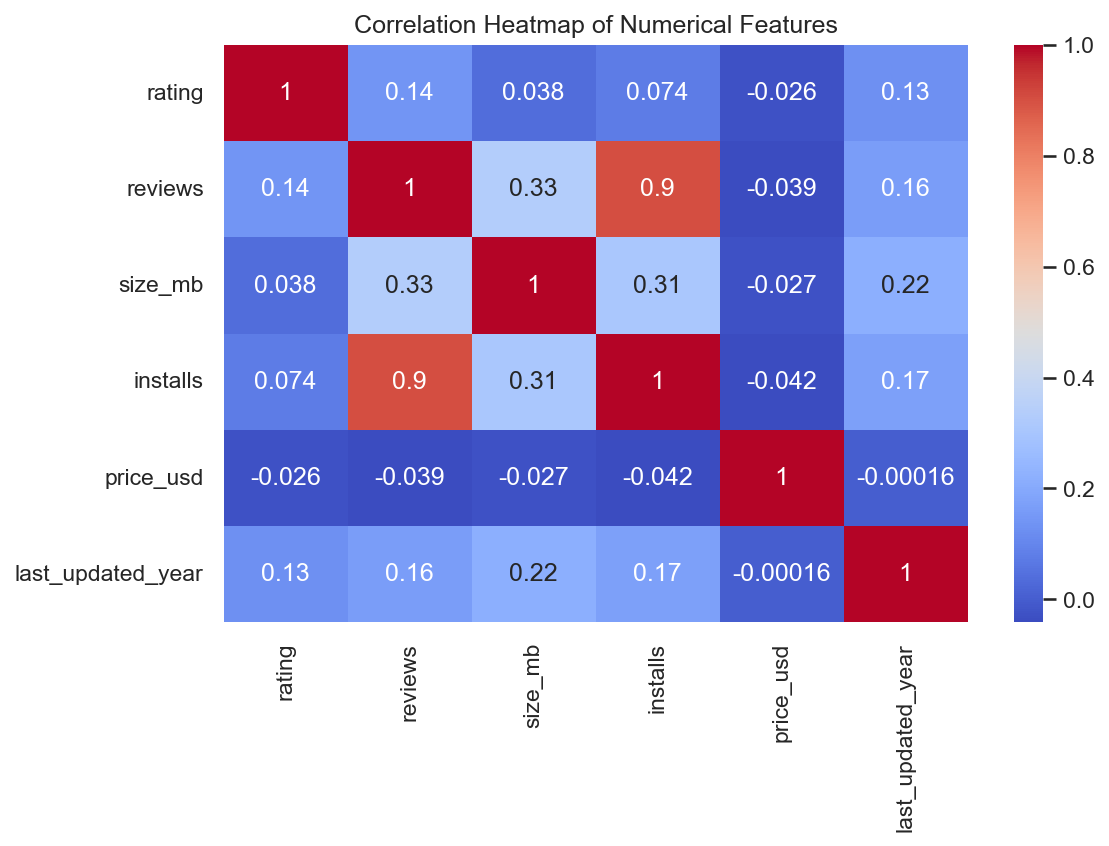

In [26]:
num_cols = ['rating', 'reviews', 'size_mb', 'installs', 'price_usd', 'last_updated_year']

plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()
